In [48]:
import pandas as pd
import seaborn as sns

train_df = pd.read_csv("/kaggle/input/titanic/train.csv")
test_df = pd.read_csv("/kaggle/input/titanic/test.csv")

train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [49]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [50]:
train_df["FamilySize"] = train_df["SibSp"] + train_df["Parch"] + 1
test_df["FamilySize"] = test_df["SibSp"] + test_df["Parch"] + 1
train_df.groupby(["FamilySize"],as_index=False)["Survived"].agg(["count","mean"])

,FamilySize,count,mean
0,1,537,0.303538
1,2,161,0.552795
2,3,102,0.578431
3,4,29,0.724138
4,5,15,0.200000
5,6,22,0.136364
6,7,12,0.333333
7,8,6,0.000000
8,11,7,0.000000


In [51]:
train_df ['Fam_type'] = pd.cut(train_df.FamilySize, [0,1,4,7,11], labels=['Solo', 'Small', 'Medium','Big'])
test_df ['Fam_type'] = pd.cut(test_df.FamilySize, [0,1,4,7,11], labels=['Solo', 'Small', 'Medium','Big'])
train_df.groupby(['Fam_type'], as_index=False)['Survived'].agg(['count','mean'])

/tmp/ipykernel_55/4041150724.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.groupby(['Fam_type'], as_index=False)['Survived'].agg(['count','mean'])


,Fam_type,count,mean
0,Solo,537,0.303538
1,Small,292,0.578767
2,Medium,49,0.204082
3,Big,13,0.000000


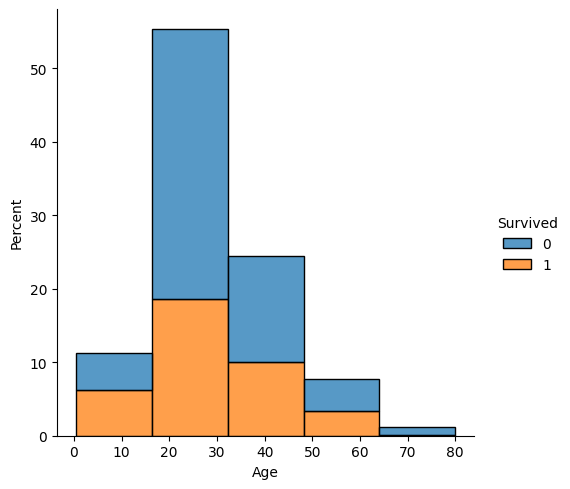

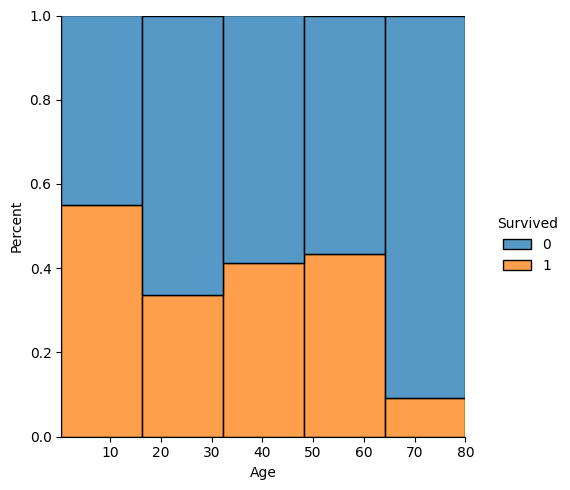

In [52]:
train_df['Age'] = train_df.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
test_df['Age'] = test_df.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
sns.displot(train_df, x='Age', hue='Survived', binwidth=17, height=5, multiple='stack', stat='percent')
sns.displot(train_df, x='Age', hue='Survived', binwidth=17, height=5,multiple = 'fill', stat='percent')

In [53]:
# def encodeAge(train):
#     train.loc[(train_df['Age']) <= 17, 'Age'] = 0
#     train.loc[(train_df['Age']) > 17 & (train_df['Age'] <= 32), 'Age'] = 1
#     train.loc[(train_df['Age']) > 32 & (train_df['Age'] <= 48), 'Age'] = 2
#     train.loc[(train_df['Age']) > 48 & (train_df['Age'] <= 64), 'Age'] = 3
#     train.loc[(train_df['Age']) > 64 & (train_df['Age'] <= 80), 'Age'] = 4
# encodeAge(train_df)

# def encodeAge(test):
#     test.loc[(test_df['Age']) <= 17, 'Age'] = 0
#     test.loc[(test_df['Age']) > 17 & (test_df['Age'] <= 32), 'Age'] = 1
#     test.loc[(test_df['Age']) > 32 & (test_df['Age'] <= 48), 'Age'] = 2
#     test.loc[(test_df['Age']) > 48 & (test_df['Age'] <= 64), 'Age'] = 3
#     test.loc[(test_df['Age']) > 64 & (test_df['Age'] <= 80), 'Age'] = 4

# encodeAge(test_df)
def encodeAge(df):
    df.loc[df['Age'] <= 17, 'Age'] = 0
    df.loc[(df['Age'] > 17) & (df['Age'] <= 32), 'Age'] = 1
    df.loc[(df['Age'] > 32) & (df['Age'] <= 48), 'Age'] = 2
    df.loc[(df['Age'] > 48) & (df['Age'] <= 64), 'Age'] = 3
    df.loc[(df['Age'] > 64) & (df['Age'] <= 80), 'Age'] = 4
    return df

# Apply to both
train_df = encodeAge(train_df)
test_df = encodeAge(test_df)

In [54]:
train_df.groupby(['Age'], as_index=False)['Survived'].mean()

,Age,Survived
0,0.0,0.539823
1,1.0,0.333333
2,2.0,0.412844
3,3.0,0.434783
4,4.0,0.090909


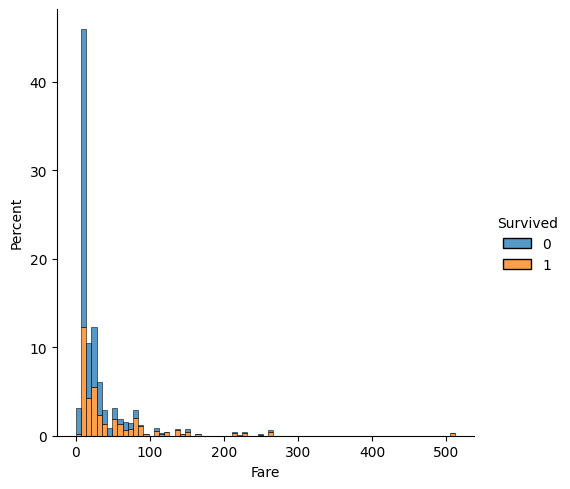

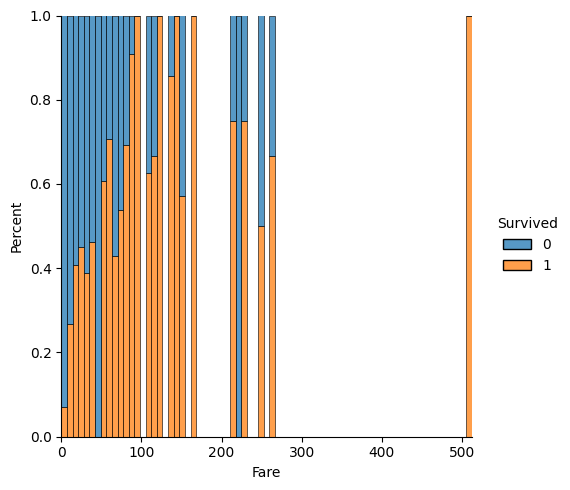

In [55]:
sns.displot(train_df, x="Fare", hue = "Survived", stat="percent",multiple= "stack", binwidth= 7,height= 5)
sns.displot(train_df, x="Fare", hue = "Survived", stat="percent",multiple= "fill", binwidth= 7, height= 5)

In [56]:
def encodeFare(train):
    train.loc[train_df['Fare'] <= 7, "Fare"] = 0
    train.loc[(train_df['Fare'] >7) & (train_df['Fare'] <= 14), "Fare"] = 1
    train.loc[(train_df['Fare'] >14) & (train_df['Fare'] <= 42.0), "Fare"] = 2
    train.loc[(train_df['Fare'] >42.0) & (train_df['Fare'] <= 512.329), "Fare"] = 3

encodeFare(train_df)
def encodeFare(test):
    test.loc[test_df['Fare'] <= 7, "Fare"] = 0
    test.loc[(test_df['Fare'] >7) & (test_df['Fare'] <= 14), "Fare"] = 1
    test.loc[(test_df['Fare'] >14) & (test_df['Fare'] <= 42.0), "Fare"] = 2
    test.loc[(test_df['Fare'] >42.0) & (test_df['Fare'] <= 512.329), "Fare"] = 3

encodeFare(test_df)

In [57]:
train_df.groupby(['Fare'], as_index=False)['Survived'].agg(['count','mean'])

,Fare,count,mean
0,0.0000,28,0.071429
1,1.0000,409,0.266504
2,2.0000,282,0.425532
3,3.0000,169,0.639053
4,512.3292,3,1.000000


In [58]:
train_df['Name']

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object

In [59]:
train_df['Title'] = train_df['Name'].str.split(pat= ",", expand=True)[1].str.split(pat=".", expand=True)[0].apply(lambda x: x.strip())
test_df['Title'] = test_df['Name'].str.split(pat=",", expand=True)[1].str.split(pat='.', expand=True)[0].apply(lambda x: x.strip())


In [60]:
train_df.groupby(['Title'], as_index=False)['Survived'].agg(['count', 'mean'])

,Title,count,mean
0,Capt,1,0.000000
1,Col,2,0.500000
2,Don,1,0.000000
3,Dr,7,0.428571
4,Jonkheer,1,0.000000
5,Lady,1,1.000000
6,Major,2,0.500000
7,Master,40,0.575000
8,Miss,182,0.697802
9,Mlle,2,1.000000


In [61]:
train_df['Title'] = train_df['Title'].replace(['Capt', 'Col', 'Major', 'Rev', 'Dr'], 'Officers')
train_df['Title'] = train_df['Title'].replace(['Mrs', 'Mme'], "Mrs")
train_df['Title'] = train_df['Title'].replace(['Miss', 'Ms', 'Mlle'], "Miss")
train_df['Title'] = train_df['Title'].replace(['Master'], "Master")
train_df['Title'] = train_df['Title'].replace(['Lady', 'the countess', 'Sir','Jonkheer', 'Don'], "VIP")
train_df['Title'] = train_df['Title'].replace(['Mr'], "Mr")

test_df['Title'] = test_df['Title'].replace(['Capt', 'Col', 'Major', 'Rev', 'Dr'], 'Officers')
test_df['Title'] = test_df['Title'].replace(['Mrs', 'Mme'], "Mrs")
test_df['Title'] = test_df['Title'].replace(['Miss', 'Ms', 'Mlle'], "Miss")
test_df['Title'] = test_df['Title'].replace(['Master'], "Master")
test_df['Title'] = test_df['Title'].replace(['Lady', 'the countess', 'Sir','Jonkheer', 'Don'], "VIP")
test_df['Title'] = test_df['Title'].replace(['Mr'], "Mr")

In [62]:
train_df.groupby(['Title'], as_index=False)["Survived"].agg(['count', "mean"])

,Title,count,mean
0,Master,40,0.575000
1,Miss,185,0.702703
2,Mr,517,0.156673
3,Mrs,126,0.793651
4,Officers,18,0.277778
5,VIP,4,0.500000
6,the Countess,1,1.000000


In [63]:
train_df.Embarked=train_df.Embarked.fillna(train_df.Embarked.mode()[0])
test_df.Embarked=test_df.Embarked.fillna(test_df.Embarked.mode()[0])

In [64]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'FamilySize',
       'Fam_type', 'Title'],
      dtype='object')

In [65]:
train_df.drop(['PassengerId','Name','SibSp','Parch','Ticket','FamilySize','Cabin'],inplace = True, axis=1)
test_df.drop(['PassengerId','Name','SibSp','Parch','Ticket','FamilySize','Cabin'],inplace = True, axis=1)
train_df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Fam_type,Title
0,0,3,male,1.0,1.0,S,Small,Mr
1,1,1,female,2.0,3.0,C,Small,Mrs
2,1,3,female,1.0,1.0,S,Solo,Miss
3,1,1,female,2.0,3.0,S,Small,Mrs
4,0,3,male,2.0,1.0,S,Solo,Mr


In [66]:
from sklearn.preprocessing import LabelEncoder

for col in ['Embarked', 'Fam_type', 'Title', 'Sex']:
    train_df[col] = LabelEncoder().fit_transform(train_df[col])
    test_df[col] = LabelEncoder().fit_transform(test_df[col])

In [67]:
train_df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Fam_type,Title
0,0,3,1,1.0,1.0,2,2,2
1,1,1,0,2.0,3.0,0,2,3
2,1,3,0,1.0,1.0,2,3,1
3,1,1,0,2.0,3.0,2,2,3
4,0,3,1,2.0,1.0,2,3,2


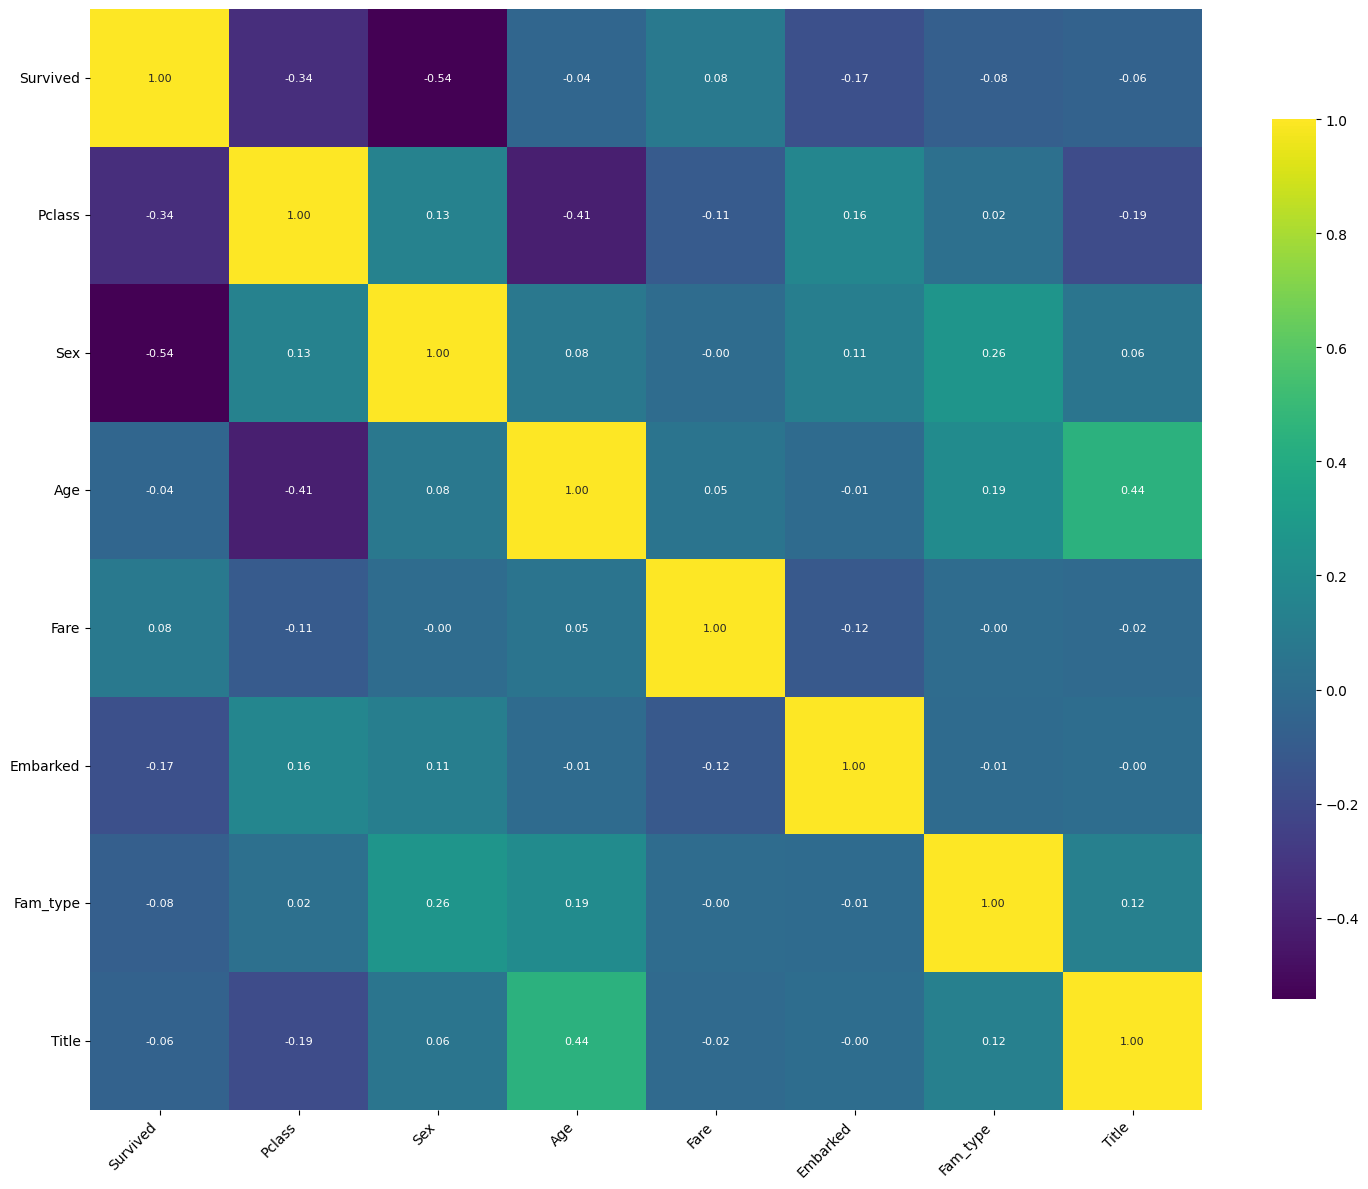

In [68]:
import matplotlib.pyplot as plt 
import seaborn as sns
correlation_matrix = train_df.corr(numeric_only=True)
plt.figure(figsize=(15,12))
heatmap = sns.heatmap(correlation_matrix,
                      annot=True,
                      cmap='viridis',
                      fmt='.2f',
                      annot_kws ={'size': 8},
                      cbar_kws={'shrink':0.8})
plt.xticks(rotation=45, ha='right', fontsize = 10)
plt.yticks(rotation=0, fontsize = 10)
plt.tight_layout()
plt.show()

In [ ]:
train_df = train_df.loc[:,['Survived', 'Pclass', 'Sex', 'Embarked','Age', 'Fare','Fam_type','Title']]
test_df = test_df.loc[:,['Pclass', 'Sex', 'Embarked','Age', 'Fare','Fam_type','Title']]
